In [2]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


import pandas as pd berfungsi untuk memasukkan pustaka Pandas ke dalam program dan menyederhanakan namanya menjadi pd agar lebih praktis.

df = pd.read_csv('Mall_Customers.csv') bertugas untuk membaca file data eksternal berformat CSV yang berisi informasi pelanggan, dan menyimpannya ke dalam memori dalam bentuk struktur tabel dua dimensi yang disebut DataFrame.

perintah df.head() digunakan untuk menampilkan lima baris pertama dari DataFrame df.

In [4]:
#cek missing values 
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

perintah df.isnull().sum()  digunakan untuk mengecek apakah ada data yang kosong di dalam tabel. saat mengelola data,  ada beberapa sel yang tidak terisi atau bernilai null. Fungsi df.isnull() ini memindai seluruh isi tabel dan menandai bagian yang kosong, sedangkan .sum() menghitung total data yang kosong tersebut untuk masing-masing kolom. dengan perintah ini, akan telihat jumlah data yang hilang di setiap kolom.

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


perintah df.describe() digunakan untuk merangkum dan melihat statistik deskriptif dari semua kolom angka yang ada di dalam tabel. perintah ini otomatis menghitung berbagai informasi penting seperti jumlah total data yang terisi (count), nilai rata-rata (mean), tingkat sebaran atau simpangan baku (std), nilai terkecil (min), titik kuartil 25%, nilai tengah atau median (50%), kuartil 75%, hingga nilai terbesar (max) untuk setiap kolom numerik.

In [6]:
dataset = df.iloc[:, 3:]
dataset.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


perintah dataset = df.iloc[:, 3:] digunakan untuk memilih atau memotong bagian tertentu dari tabel utama df berdasarkan posisi indeks baris dan kolomnya. 

Tanda titik dua (:) di sebelah kiri koma untuk mengambil semua baris yang ada di dalam tabel. 

kode 3: di sebelah kanan koma berfungsi untuk mengambil kolom mulai dari indeks ke-3 sampai seterusnya, sedangkan kolom-kolom sebelum indeks ke-3 diabaikan. 

Hasil irisan data tersebut kemudian disimpan ke dalam variabel baru bernama dataset

baris dataset.head() digunakan untuk menampilkan lima baris pertama dari data yang sudah disaring



In [7]:
x = df.iloc[:, 3]
y = df.iloc[:, 4]


perintah x = df.iloc[:, 3] dan y = df.iloc[:, 4] digunakan untuk mengambil atau memisahkan kolom tertentu dari tabel df secara spesifik berdasarkan nomor indeks posisinya. 

Tanda titik dua (:) di sebelah kiri koma berarti ingin mengambil semua baris data, sementara angka di sebelah kanan koma menunjukkan nomor kolom yang ingin diambil. 

Hasil irisan data dari masing-masing kolom ini kemudian disimpan ke dalam variabel x dan y agar bisa digunakan secara terpisah.

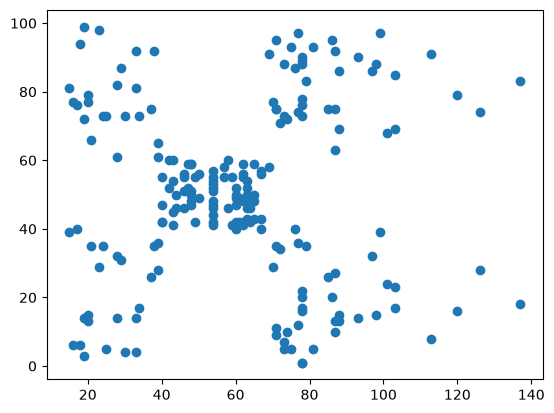

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

import matplotlib.pyplot as plt digunakan untuk memasukkan pustaka Matplotlib ke dalam program dan memberi nama dan lebih mudah dipanggil. 

plt.scatter(x, y) berfungsi untuk membuat scatter plot, variabel x dan y dimasukkan sebagai koordinat titik-titik data untuk menampilkan sebaran dan pola hubungan antar data pada bidang dua dimensi.

 perintah plt.show() digunakan untuk mengeksekusi dan menampilkan grafik visual.

c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known

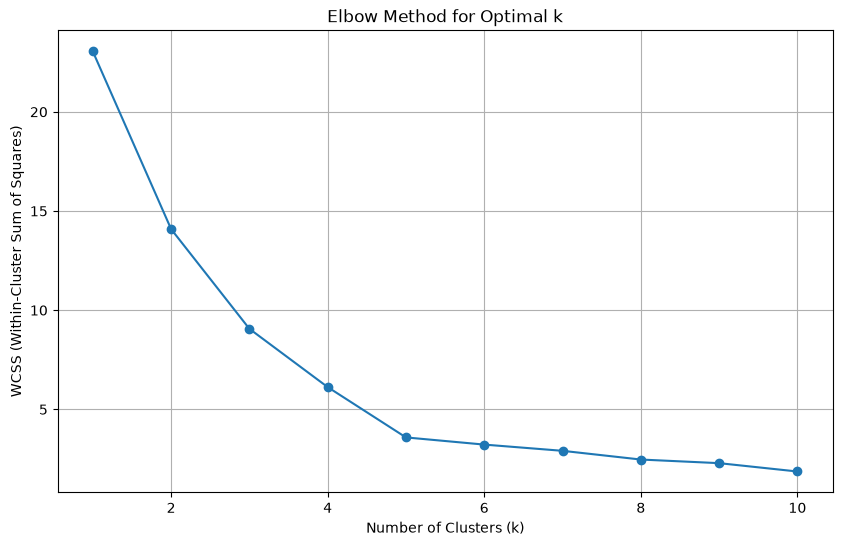

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

#scaling data dengan minmaxscaler
scaler = MinMaxScaler()

#mengambil kolom X (index 3) dan Y (index 4) dari dataframe
X = pd.DataFrame(
    {'Annual Income (k$)': x, 'Spending Score (1-100)': y}
)

X_scaled = scaler.fit_transform(X)

#menentukan jumlah klaster optimal menggunakan elbow method
wcss = []
for i in range(1, 11):  # Coba k dari 1 sampai 10
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

#membuat plot elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

- matplotlib.pyplot untuk menggambar grafik
- KMeans untuk algoritma pengelompokan,
- serta MinMaxScaler untuk menyamakan skala nilai data. 
objek scaler diinisialisasi dan data dari variabel x serta y digabungkan ke dalam sebuah struktur DataFrame baru dengan nama X.

Data di dalam X kemudian diproses menggunakan scaler.fit_transform(X) supaya seluruh fiturnya dalam rentang skala yang setara. 

Setelah data siap, kode menjalankan sebuah loop dari angka 1 hingga 10 untuk menguji variasi jumlah klaster. Di setiap perulangan, model K-Means dibuat dan dilatih menggunakan data yang udah diskalakan, lalu nilai inersia atau WCSS (Within-Cluster Sum of Squares) disimpan ke dalam sebuah wadah list bernama wcss. 

Hasil perulangan tersebut divisualisasikan ke dalam bentuk grafik garis menggunakanMatplotli b. Grafik ini memetakan hubungan antara jumlah klaster dan nilai WCSS, judul, label sumbu, dan grid, jadi dapat menganalisis bentuk elbow pada grafik.

c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


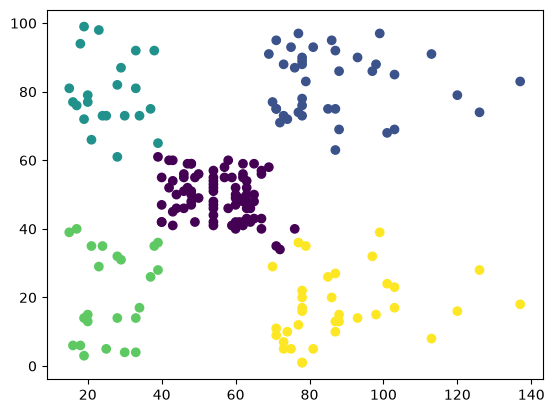

In [11]:
#dari elbow method, nilai k optimal untuk data ini adalah 5
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

#plot hasil klaster
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

kmeans = KMeans(n_clusters=5) berfungsi untuk menginisialisasi algoritma K-Means dengan menetapkan parameter jumlah klaster sama dengan 5, yang merujuk pada hasil analisis metode Elbow sebelumnya. 

perintah kmeans.fit(X) digunakan untuk melatih model menggunakan data X agar algoritma dapat mempelajari pola, menentukan titik centroid, dan membagi data ke dalam 5 kelompok klaster tersebut.

kemudian menggunakan plt.scatter(x, y, c=kmeans.labels_) untuk memetakan data pada sumbu x dan y. parameter c=kmeans.labels_ secara otomatis memberikan warna yang berbeda-beda pada setiap titik data berdasarkan label klaster hasil prediksinya. 

perintah plt.show() dijalankan untuk menampilkan grafik akhir

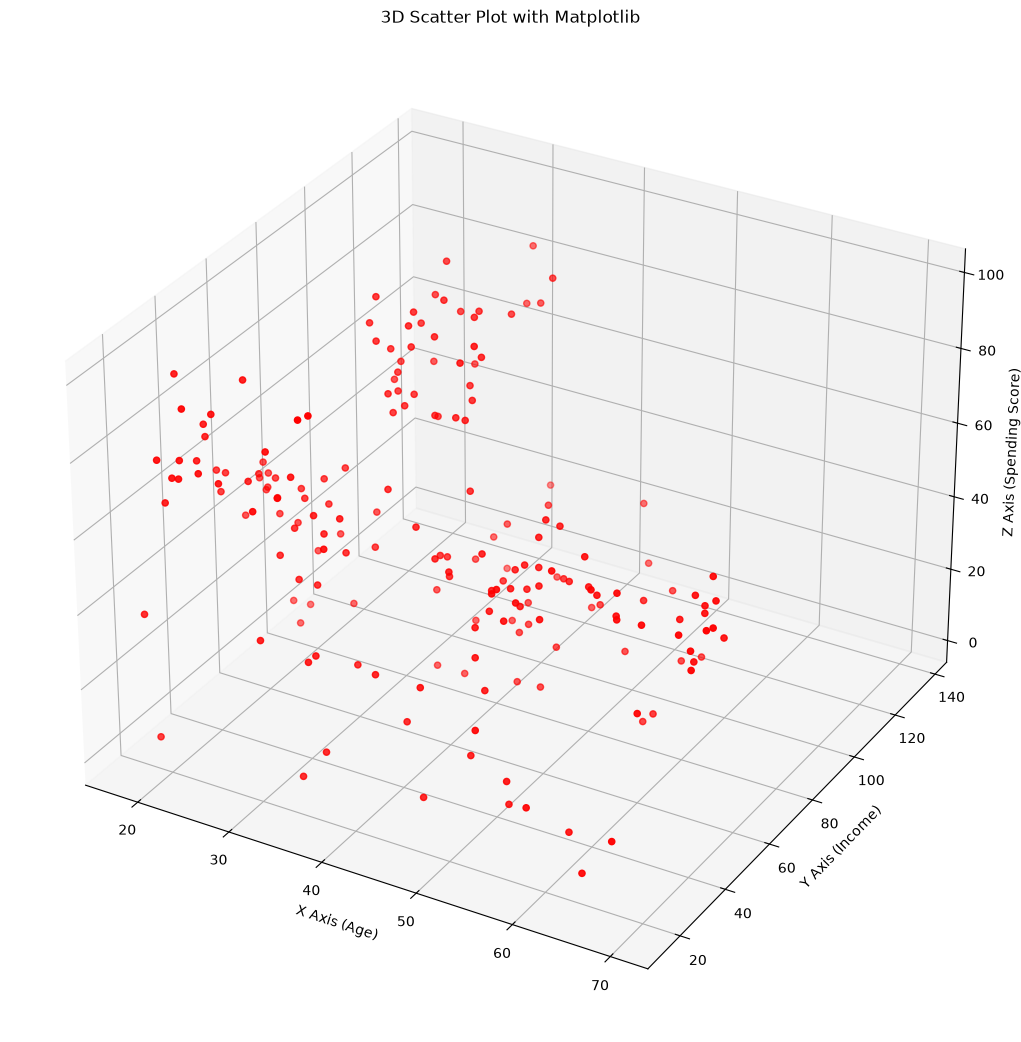

In [12]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

#data age, annual income, dan spending score
x = df.iloc[:, 2]
y = df.iloc[:, 3]
z = df.iloc[:, 4]

#membuat plot 3D
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

#plot data
ax.scatter(x, y, z, c='red', marker='o')

#label sumbu
ax.set_xlabel('X Axis (Age)')
ax.set_ylabel('Y Axis (Income)')
ax.set_zlabel('Z Axis (Spending Score)')

plt.title('3D Scatter Plot with Matplotlib')
plt.show()

baris from mpl_toolkits.mplot3d import Axes3D dan import numpy as np untuk menyediakan modul khusus grafik 3D serta pengolahan data numerik. 

variabel x, y, dan z diisi dengan mengambil kolom indeks age(2), Annual Income(3), dan Spending Score(4) dari seluruh baris DataFrame menggunakan metode .iloc.   

fig = plt.figure(figsize=(13, 13)) untuk mengatur ukuran jendela gambar, yang kemudian dikonfigurasi ke dalam mode proyeksi tiga dimensi menggunakan ax = fig.add_subplot(111, projection='3d'). P

perintah ax.scatter(x, y, z, c='red', marker='o') bertugas untuk memetakan titik-titik koordinat data ke dalam ruang 3D dengan menggunakan warna merah (c='red') dan bentuk penanda lingkaran (marker='o').

fungsi ax.set_xlabel, ax.set_ylabel, dan ax.set_zlabel untuk memberi keterangan pada masing-masing sumbu.

 plt.title() dan plt.show() untuk menampilkan grafik 3D ke layar

c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known

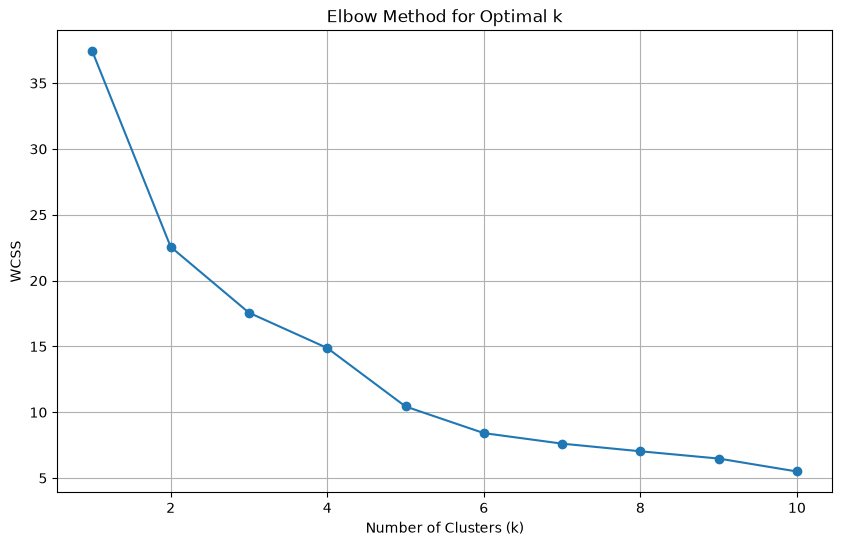

In [14]:
#menggabungkan data X, Y, Z menjadi array untuk clustering
X = np.array(list(zip(x, y, z)))

#scaling data dengan minmaxscaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#menentukan jumlah klaster optimal menggunakan elbow method
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

#visualisasi elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

perintah X = np.array(list(zip(x, y, z))) berfungsi untuk menggabungkan tiga variabel terpisah (x, y, dan z) menjadi sebuah array matriks dua dimensi menggunakan NumPy.

baris scaler = MinMaxScaler() dan X_scaled = scaler.fit_transform(X) digunakan untuk melakukan normalisasi data.

ketiga, blok loop for i in range(1, 11): bertugas untuk menguji berbagai variasi jumlah klaster dari 1 hingga 10. 
Di setiap iterasi, model K-Means diinisialisasi dengan parameter n_clusters=i dan random_state=42 agar hasil acaknya konsisten, lalu dilatih menggunakan data yang sudah diskalakan (X_scaled).

WCSS (Within-Cluster Sum of Squares) dari setiap model kemudian diambil melalui atribut kmeans.inertia_ dan disimpan ke dalam list wcss.  

c:\Users\MSI MODERN 14\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


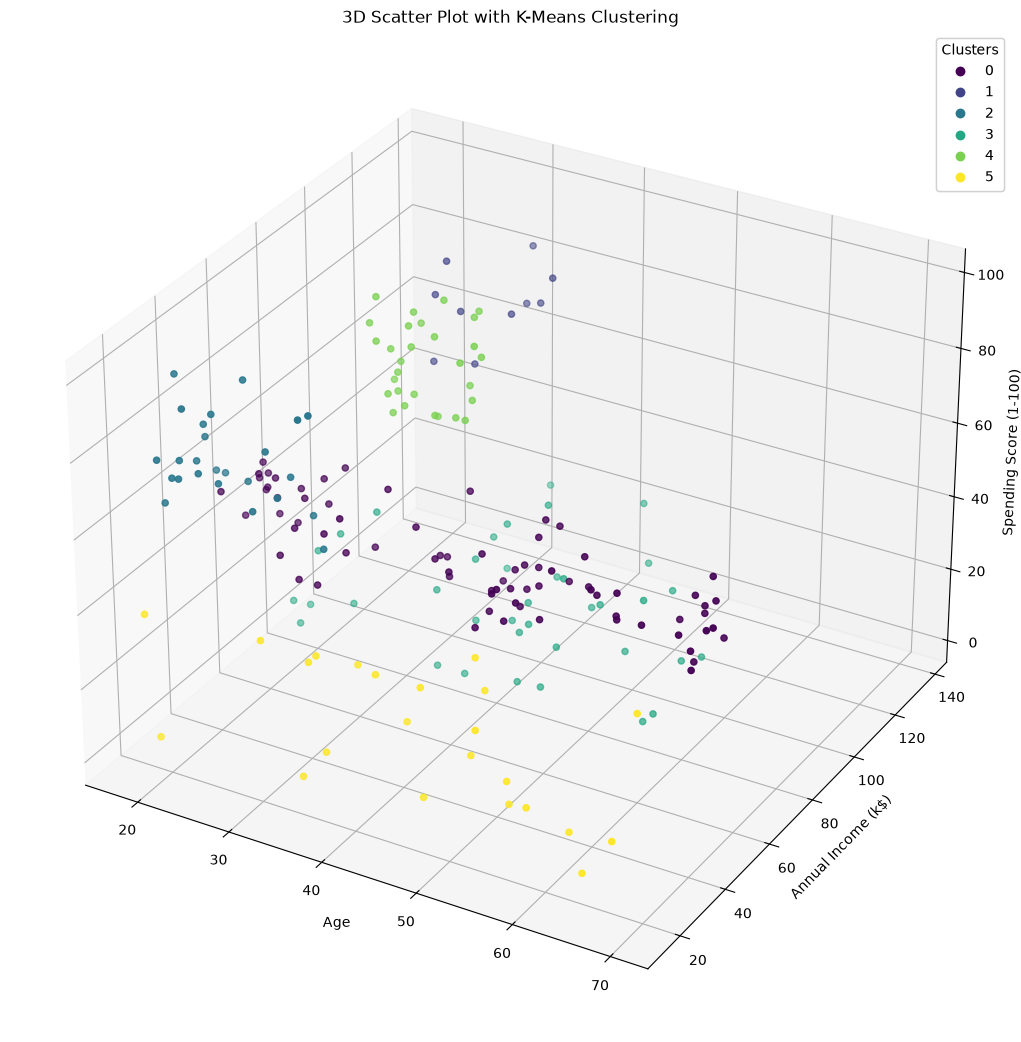

In [15]:
#pilih k optimal setelah melihat elbow
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X)

#menambahkan hasil klaster ke dataframe
df['Cluster'] = clusters

#visualisasi 3D hasil K-Means

#plot data dengan warna berdasarkan klaster
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

#plot setiap titik dengan warna sesuai klaster
scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o')

#label sumbu
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

#menampilkan Legenda klaster
legend1 = ax.legend(*scatter.legend_elements(), title='Clusters')
ax.add_artist(legend1)

plt.title('3D Scatter Plot with K-Means Clustering')
plt.show()

kmeans = KMeans(n_clusters=6, random_state=42) berfungsi untuk menginisialisasi algoritma K-Means dengan 6 kelompok klaster dan menggunakan random_state=42 agar titik awal pusat klaster konsisten setiap kali kode dijalankan.

perintah clusters = kmeans.fit_predict(X) lalu melatih model dan menghasilkan label klaster untuk setiap baris data di dalam array X.   

baris df['Cluster'] = clusters digunakan untuk menyisipkan kolom baru bernama 'cluster' ke dalam tabel utama DataFrame df untuk menyimpan hasil pengelompokan. 

plt.figure() dan fig.add_subplot(111, projection='3d') untuk menyiapkan kanvas gambar 3D berukuran 13x13.

fungsi ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o') dipakai untuk memetakan koordinat titik-titik data berdasarkan kolom Age, Annual Income, dan Spending Score. 

parameter c=clusters dan peta warna cmap='viridis' secara otomatis memberikan warna yang berbeda untuk setiap kelompok klaster. 

pemberian label pada tiap sumbu dengan (ax.set_xlabel, ax.set_ylabel, ax.set_zlabel), pembuatan kotak keterangan otomatis melalui fungsi ax.legend(*scatter.legend_elements()) untuk memperjelas kategori klaster